# 04 - Evaluation on the held-out test set

Run notebook 03 (or `python -m src.train`) first. This notebook calls `src/evaluate.py`, which loads every trained model and scores it on the 360 test patients that were never used for training or model choice.

**Metrics.** AUROC is primary (as in the paper): how well the model ranks patients who decline above those who don't, across all thresholds. Because only 20% of patients decline, accuracy alone is misleading (predicting "no decline" for everyone scores 80%), so we also report PR-AUC, precision, recall and F1 at the threshold chosen on training data.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.precision", 3)
from IPython.display import Image, display
from src import config
from src.evaluate import main as evaluate

In [2]:
evaluate('drop_outcome')

                Model  CV AUROC (train)  Test AUROC  PR-AUC  Accuracy  Precision  Recall    F1  Threshold
Logistic Regression *             0.753       0.764   0.513     0.725      0.398   0.699 0.507      0.210
                  KNN             0.719       0.705   0.406     0.664      0.338   0.685 0.452      0.180
                  SVM             0.733       0.772   0.488     0.719      0.387   0.658 0.487      0.220
        Random Forest             0.741       0.750   0.457     0.714      0.375   0.616 0.466      0.230
    Gradient Boosting             0.738       0.739   0.438     0.622      0.309   0.699 0.429      0.180
      Voting Ensemble             0.752       0.761   0.485     0.683      0.361   0.726 0.482      0.200



Final model Logistic Regression: test AUROC 0.764 (95% CI 0.695-0.823)



Ablation:
                   Feature set  AUROC  CI low  CI high
          Without Demographics  0.759   0.689    0.814
    Without Cancer & treatment  0.705   0.630    0.766
             Without Diagnoses  0.758   0.696    0.815
           Without Medications  0.768   0.699    0.823
           Without Utilization  0.764   0.694    0.819
                Without Vitals  0.769   0.702    0.821
                  Without Labs  0.739   0.675    0.798
Without Baseline PROMIS scores  0.735   0.667    0.796
   Only baseline PROMIS scores  0.630   0.558    0.699

Top features:
           feature  importance    std
             stage      0.0442 0.0136
      albumin_g_dl      0.0313 0.0111
      baseline_gmh      0.0302 0.0079
      baseline_gph      0.0272 0.0066
       ecog_status      0.0175 0.0095
   hemoglobin_g_dl      0.0166 0.0121
 num_comorbidities      0.0130 0.0071
               age      0.0059 0.0044
     chemo_regimen      0.0018 0.0020
depression_history      0.0014 0.0033


## Model comparison

In [3]:
pd.read_csv(config.RESULTS_DIR / 'model_comparison_drop_outcome.csv')

,Model,CV AUROC (train),Test AUROC,PR-AUC,Accuracy,Precision,Recall,F1,Threshold
0,Logistic Regression *,0.753,0.764,0.513,0.725,0.398,0.699,0.507,0.21
1,KNN,0.719,0.705,0.406,0.664,0.338,0.685,0.452,0.18
2,SVM,0.733,0.772,0.488,0.719,0.387,0.658,0.487,0.22
3,Random Forest,0.741,0.750,0.457,0.714,0.375,0.616,0.466,0.23
4,Gradient Boosting,0.738,0.739,0.438,0.622,0.309,0.699,0.429,0.18
5,Voting Ensemble,0.752,0.761,0.485,0.683,0.361,0.726,0.482,0.20


## ROC curves

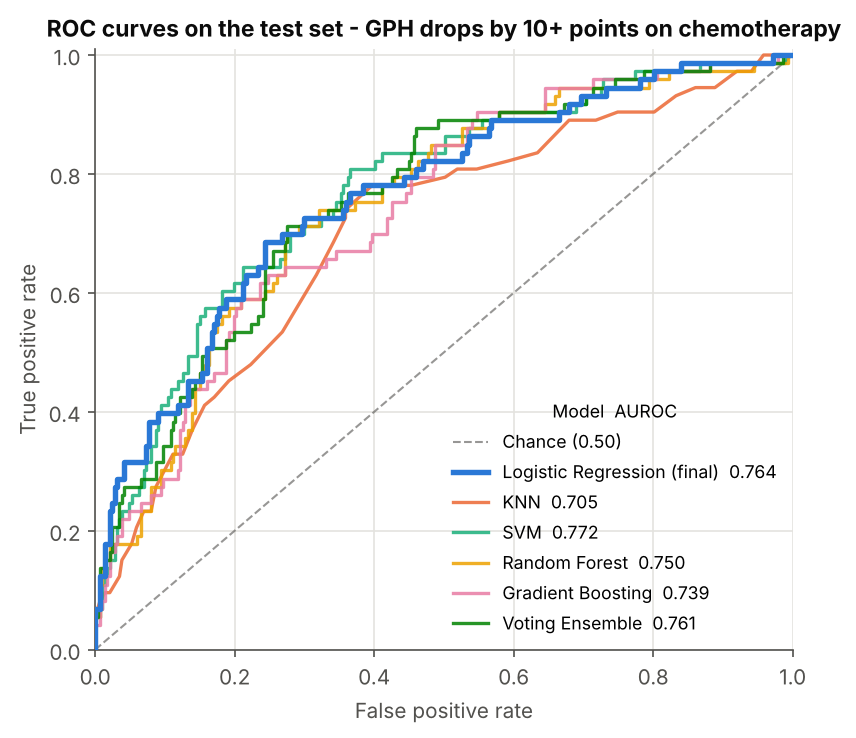

In [4]:
display(Image(config.FIGURES_DIR / '11_roc_curves_drop_outcome.png', width=600))

## Confusion matrix of the final model
Read it as: of the patients who really declined (bottom row), how many did we catch (recall); of the patients we flagged (right column), how many really declined (precision).

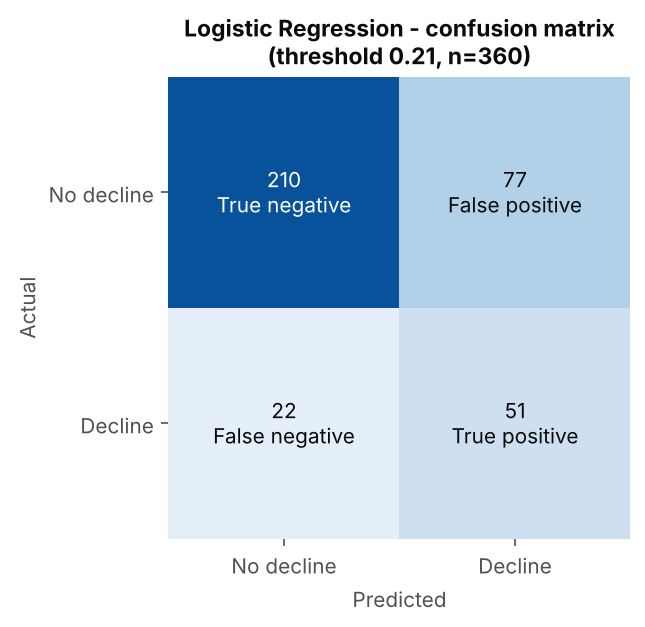

In [5]:
display(Image(config.FIGURES_DIR / '12_confusion_matrix_drop_outcome.png', width=450))

## Which inputs drive the prediction
Permutation importance: shuffle one input across patients and measure how much test AUROC falls.

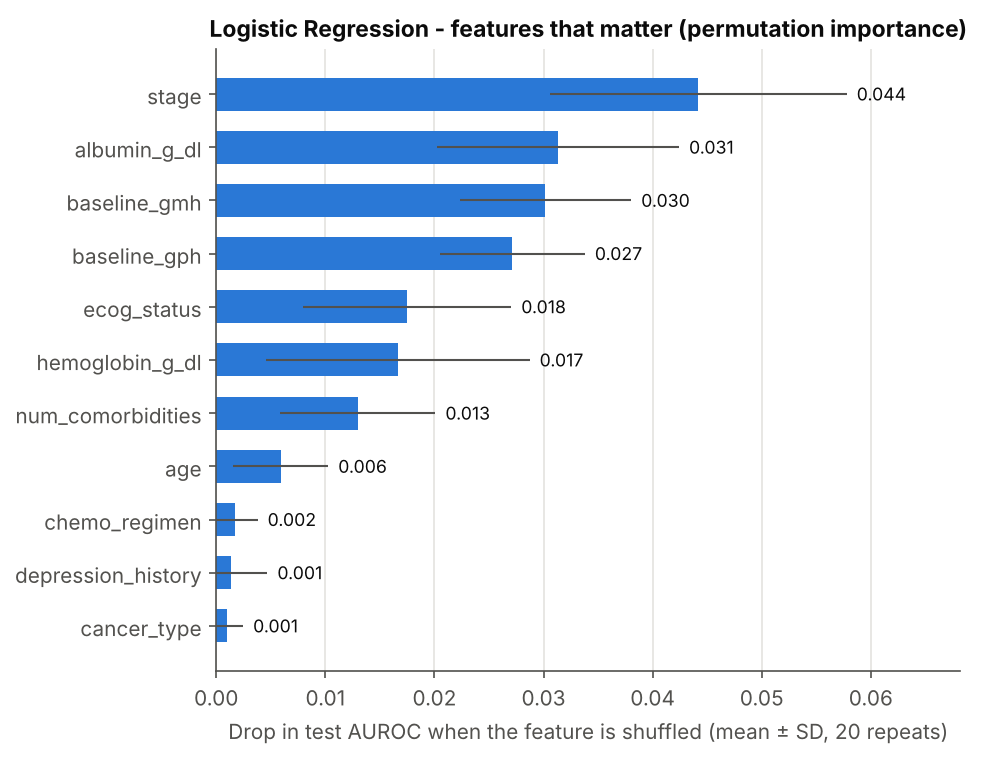

In [6]:
display(Image(config.FIGURES_DIR / '13_feature_importance_drop_outcome.png', width=650))

## Ablation (paper Table 2)
Retrain the final model without one group of features at a time. A big drop means the group carried information the others could not replace.

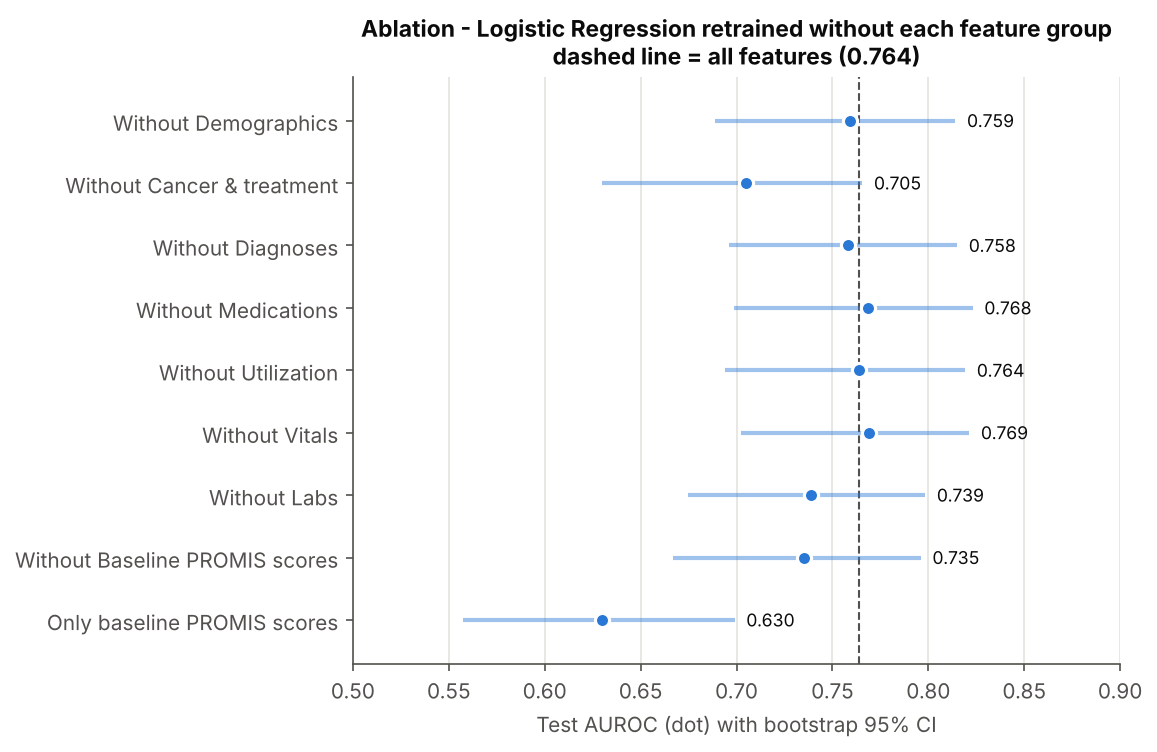

,Feature set,AUROC,CI low,CI high
0,Without Demographics,0.759,0.689,0.814
1,Without Cancer & treatment,0.705,0.630,0.766
2,Without Diagnoses,0.758,0.696,0.815
3,Without Medications,0.768,0.699,0.823
4,Without Utilization,0.764,0.694,0.819
5,Without Vitals,0.769,0.702,0.821
6,Without Labs,0.739,0.675,0.798
7,Without Baseline PROMIS scores,0.735,0.667,0.796
8,Only baseline PROMIS scores,0.630,0.558,0.699


In [7]:
display(Image(config.FIGURES_DIR / '14_ablation_drop_outcome.png', width=700))
pd.read_csv(config.RESULTS_DIR / 'ablation_drop_outcome.csv')

## Comparison with the paper

| | Paper (Stanford STARR, real EHR) | Ours (synthetic) |
|---|---|---|
| Patients | 1,252 | 1,800 (1,440 train / 360 test) |
| Features | 933 | 52 raw, 89 after encoding |
| Best AUROC, drop outcome | Ensemble Voting 0.771 | Logistic Regression (LASSO) 0.764 test, 0.753 CV |
| Logistic models | LASSO 0.764, Elastic Net 0.767 | LASSO 0.764 |
| Voting Ensemble | 0.771 (best) | 0.761 (CV 0.752, essentially tied with LR) |
| KNN | worst (0.598) | worst (0.705) |
| Baseline PROMIS scores alone | 0.770 | 0.630 |

The overall ranking matches the paper: regularised logistic regression and the ensemble on top, KNN last. One difference: in the paper the baseline scores alone almost matched the full model; in our synthetic data cancer stage, labs and ECOG carry more of the signal.

**Limitations.** The data are synthetic, so results show the method works, not clinical validity. Single test split of 360 patients: the bootstrap CI shows roughly ±0.06 uncertainty in AUROC, so small differences between models are not meaningful.